<a href="https://colab.research.google.com/github/Preenon-ngs/Preenon-ngs/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predicting Diabetes with Multilayer Perceptrons**
In the first part, we will go through the inner workings of a neural network, how to build
our own neural network using Python libraries such as Keras, as well as the end-to-end
machine learning workflow. In this part, we will apply what we have learned to build a
multilayer perceptron (MLP) that can predict whether a patient is at risk of diabetes. This
marks the first neural network project that we will build from scratch.
In this project, we will cover the following topics:
1. Understanding the problem that we're trying to tackle—diabetes mellitus
2. How AI is being used in healthcare today, and how AI will continue to transform
healthcare
3. An in-depth analysis of the diabetes mellitus dataset, including data
visualization using Python
Understanding MLPs, and the model architecture that we will use
4. A step-by-step guide to implement and train an MLP with Keras
5. Analysis of our results

Diabetes – understanding the problem
Diabetes is a chronic medical condition that is associated with elevated blood sugar levels
in the body. Diabetes often leads to cardiovascular disease, stroke, kidney damage, and
long-term damage to the extremities (that is, limbs and eyes).
It is estimated that there are 415 million people in the world suffering from diabetes, with
up to 5 million deaths every year attributed to diabetes-related complications. In the United
States, diabetes is estimated to be the seventh highest cause of death. Clearly, diabetes is a
cause of concern to the wellbeing of modern society.
Diabetes can be divided into two subtypes: type 1 and type 2. Type 1 diabetes results from
the body's inability to produce sufficient insulin. Type 1 diabetes is relatively rare
compared to type 2 diabetes, and it only accounts for approximately 5% of diabetes.
Unfortunately, the exact cause of type 1 diabetes is unknown and therefore, it is difficult to
prevent the onset of type 1 diabetes.
Type 2 diabetes results from the body's gradual resistance to insulin. Type 2 diabetes is the
prevalent form of diabetes in the world, and it is caused by excessive body weight,
irregular exercise, and a poor diet. Fortunately, the onset of type 2 diabetes can be
prevented and reversed if diagnosed early.
One of the barriers for early detection and diagnosis of diabetes is that the early stages of
diabetes are often non-symptomatic. People who are on the path to diabetes (also known as
prediabetes) often do not know that they have diabetes until it is too late. How can we use machine learning to address this problem? If we have a labeled dataset
that contains some vital measurements of patients (for example, age and blood insulin
level), as well as a true label indicating the onset of diabetes in the patient sometime after
the measurements were taken, then we can train a neural network (machine learning
classifier) on this data and use it to make predictions on new patients:

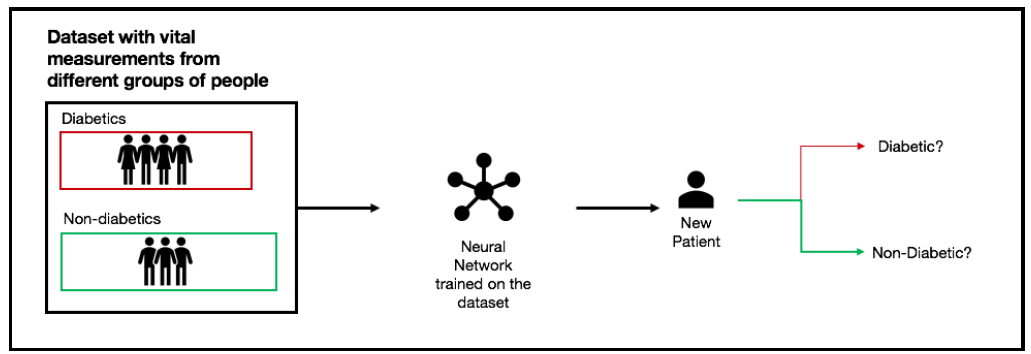

**Automated diagnosis**

Let's zoom in on automated diagnosis as that is the area of concern for this project. Experts
believe that AI will greatly augment the way medical diagnosis is conducted. At the
moment, most medical diagnosis is performed by skilled medical experts. In the case of
medical diagnosis through images (such as X-rays and MRI scans), skilled radiologists are
required to provide their expertise in the diagnostic process. These skilled medical
professionals go through years of rigorous training before being certified, and there is a
shortage of these medical experts in certain countries, which contributes to poor outcomes.
The role of AI is to augment these experts and to offload low-level routine diagnosis, which
can be done by an AI agent with a high degree of accuracy.
This ties back to our original problem statement; using AI to predict which patients are at
risk of diabetes. As we shall see, we can use machine learning and neural networks to make
this prediction. In this project, we will design and implement an MLP that can predict the
onset of diabetes using machine learning.

**The diabetes mellitus dataset**

The dataset that we will be using for this project comes from the Pima Indians Diabetes
dataset, as provided by the National Institute of Diabetes and Digestive and Kidney
Diseases.
The Pima Indians are a group of native Americans living in Arizona, and they are a highly
studied group of people due to their genetic predisposition to diabetes. It is believed that
the Pima Indians carry a gene that allows them to survive long periods of starvation. This
thrifty gene allowed the Pima Indians to store in their bodies whatever glucose and
carbohydrates they may eat, which is genetically advantageous in an environment where
famines were common.
However, as society modernized and the Pima Indians began to change their diet to one of
processed food, the rate of type 2 diabetes among them began to increase as well. Today,
the incidence of type 2 diabetes among the Pima Indians is the highest in the world. This
makes them a highly studied group of people, as researchers attempt to find the genetic
link of diabetes among the Pima Indians.
The Pima Indians diabetes dataset consists of diagnostic measurements collected from a
sample of female Pima Indians, along with a label indicating whether the patient developed
diabetes within five years of the initial measurement. In the next section, we'll perform
exploratory data analysis on the Pima Indians diabetes dataset to uncover important
insights about the data.

**Exploratory data analysis **


Let's dive into the dataset to understand the kind of data we are working with. We import
the dataset into pandas:

In [ ]:
import pandas as pd
df = pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


It looks like there are nine columns in the dataset, which are as follows:
Pregnancies: Number of previous pregnancies
Glucose: Plasma glucose concentration
BloodPressure: Diastolic blood pressure
SkinThickness: Skin fold thickness measured from the triceps
Insulin : Blood serum insulin concentration
BMI: Body mass index
DiabetesPedigreeFunction: A summarized score that indicates the genetic
predisposition of the patient for diabetes, as extrapolated from the patient's
family record for diabetes
Age: Age in years
Outcome: The target variable we are trying to predict, 1 for patients that
developed diabetes within five years of the initial measurement, and 0 otherwise
Let's start by visualizing the distribution of the nine variables in the dataset. We can do this
by plotting a histogram:

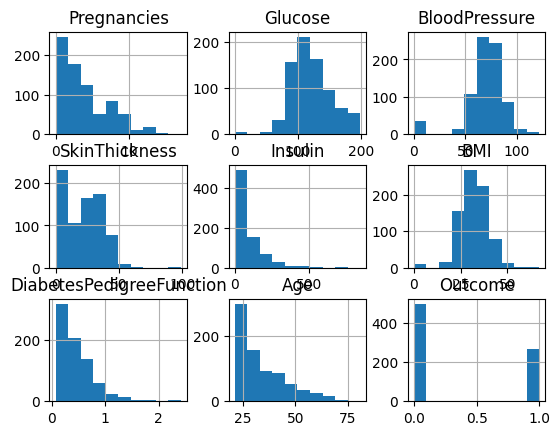

In [ ]:
from matplotlib import pyplot as plt
df.hist()
plt.show()

The histogram provides some interesting insights into the data. From the histogram for
Age, we can see that most of the data was collected from young people, with the most
common age group between 20-30 years old. We can also see that the distribution for BMI,
BloodPressure, and Glucose concentration is normally distributed (that is, a bell curve
shape), which is what we we expect when we collect such statistics from a population.
However, note that the tail of the Glucose concentration distribution shows some rather
extreme values. It appears that there are people with plasma Glucose concentration that is
almost 200. On the opposite end of the distribution, we can see that there are people with 0
values for BMI, BloodPressure, and Glucose. Logically, we know that it is not possible to
have a 0 value for these measurements. Are these missing values? We shall explore more in
the next section on data preprocessing.
If we look at the distribution for the number of previous Pregnancies, we can see some
outliers as well. We can see that some patients had more than 15 previous pregnancies.
While that may not be entirely surprising, we should keep such outliers in mind when we
do our analysis, as it can skew our results.
The distribution of outcome shows that approximately 65% of the population belongs to
class 0 (no diabetes), while the remaining 35% belongs to class 1 (diabetes). When building
a machine learning classifier, we should always keep in mind the distribution of classes in
our training data. In order to ensure that our machine learning classifier works well in the
real world, we should ensure that the distribution of classes in our training data mirrors
that of the real world. In this case, the distribution of the classes does not match those in the
real world, as it is estimated by the World Health Organization (WHO) that only 8.5% of
the world population suffers from diabetes.
We do not need to worry about the distribution of classes in our training
data for this project, as we are not going to deploy our classifier in the real
world. Nevertheless, it is a good practice for data scientists and machine
learning engineers to check the distribution of classes in the training data,
in order to ensure strong model performance in the real world.

Lastly, it is important to note that the variables are on different scales. For example, the
DiabetesPedigreeFunction variable ranges from 0 to ~2.5, while the Insulin variable
ranges from 0 to ~800. This difference in scale can cause problems in training our neural
network, as variables with larger scales tend to dominate variables with smaller scales. In
the next section on data preprocessing, we will look at how we can standardize the
variables.
We can also plot a density plot to investigate the relationship between each variable and the
target variable. To do so, we will use seaborn. seaborn is a Python data visualization library
based on matplotlib.
The following code snippet shows how to plot a density plot for each variable. To visualize
the difference in distribution between diabetics and non-diabetics, we will also plot them
separately on each plot:

<ipython-input-4-9f057e3dee10>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df.Outcome == 0][col], hist=False, axlabel= False,
<ipython-input-4-9f057e3dee10>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df.Outcome == 1][col], hist=False, axlabel= False,
<

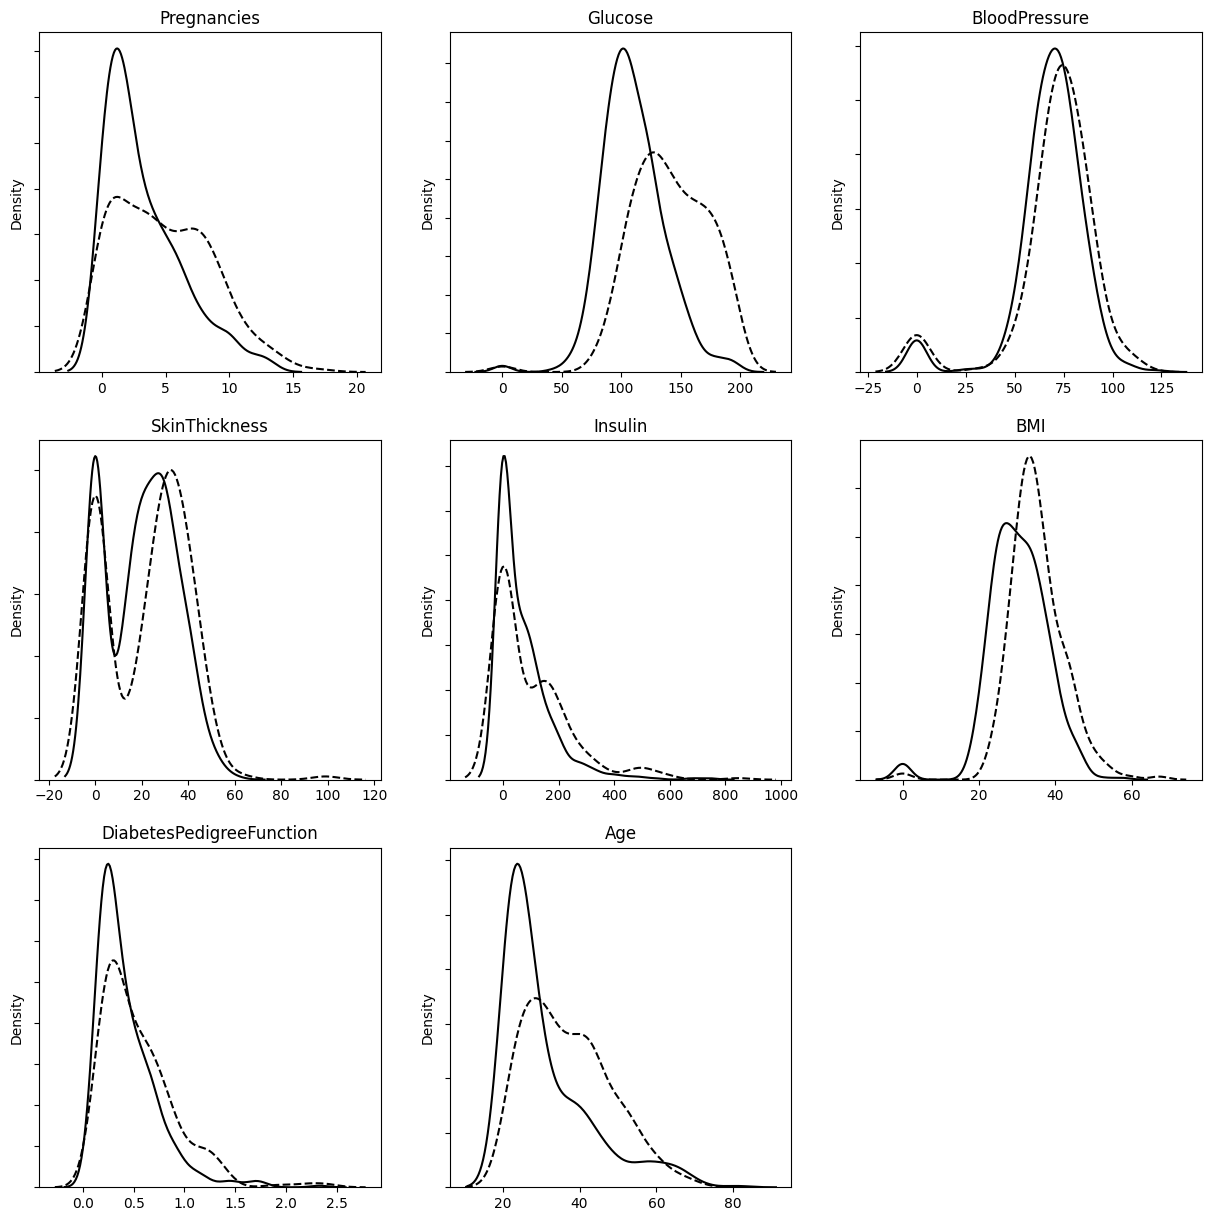

In [ ]:
import seaborn as sns
# create a subplot of 3 x 3
plt.subplots(3,3,figsize=(15,15))
# Plot a density plot for each variable
for idx, col in enumerate(df.columns):
  ax = plt.subplot(3,3,idx+1)
  ax.yaxis.set_ticklabels([])
  sns.distplot(df.loc[df.Outcome == 0][col], hist=False, axlabel= False,
  kde_kws={'linestyle':'-',
  'color':'black', 'label':"No Diabetes"})
  sns.distplot(df.loc[df.Outcome == 1][col], hist=False, axlabel= False,
  kde_kws={'linestyle':'--',
  'color':'black', 'label':"Diabetes"})
  ax.set_title(col)
# Hide the 9th subplot (bottom right) since there are only 8 plots
plt.subplot(3,3,9).set_visible(False)
plt.show()

The preceding density plots look complicated, but let's focus on each individual plot and
see what insights can we gain. If we look at the plot for the Glucose variable, we can see
that among the non-diabetics (solid line), the curve has a normal distribution centered
around the value 100. This tells us that among non-diabetics, most people have a blood
glucose value of 100 mg/dL. On the other hand, if we look at the Diabetics (dashed line),
the curve is wider and is centered around a value of 150. This tells us that diabetics tends to
have a wider range of blood glucose value, and the average blood glucose value is around
150 mg/dL. Therefore, there is a significant difference in blood glucose values for diabetes
vs non-diabetics. A similar analysis can also be made for the variable BMI and Age. In other
words, the Glucose, BMI, and Age variables are strong predictors for diabetes. People with
diabetes tend to have higher blood glucose level, higher BMI, and are older.
On the other hand, we can see that for variables such as BloodPressure and
SkinThickness, there is no significant difference in the distribution between diabetics and
non-diabetics. The two groups of people tend to have similar blood pressure and skin
thickness values. Therefore, BloodPressure and SkinThickness are poorer predictors
for diabetes.

**Data preprocessing**

In the previous section, Exploratory data analysis, we have discovered that there are 0 values
in certain columns, which indicates missing values. We have also seen that the variables
have different scales, which can negatively impact model performance. In this section, we
will perform data preprocessing to handle these issues.

**Handling missing values**
First, let's call the isnull() function to check whether there are any missing values in the
dataset:

In [ ]:
df.isnull().any()

,0
Pregnancies,False
Glucose,False
BloodPressure,False
SkinThickness,False
Insulin,False
BMI,False
DiabetesPedigreeFunction,False
Age,False
Outcome,False


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


We can see that there are 768 rows of data, and the Pregnancies, Glucose,
BloodPressure, SkinThickness, Insulin, and BMI columns have a minimum value of
0.
This doesn't quite make sense. The measurements for Glucose, BloodPressure,
SkinThickness, Insulin, and BMI should never be 0. This is an indication that there are
missing values in our dataset. The values were probably recorded as 0 due to certain issues
during data collection. Perhaps the equipment was faulty, or the patient was unwilling to
have their measurements taken. In any case, we need to handle these 0 values. Let's take a look at how many 0 values are
there in each column to understand the extent of the problem:

In [ ]:
print("Number of rows with 0 values for each variable")
for col in df.columns:
  missing_rows = df.loc[df[col]==0].shape[0]
  print(col + ": " + str(missing_rows))

Number of rows with 0 values for each variable
Pregnancies: 111
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
DiabetesPedigreeFunction: 0
Age: 0
Outcome: 500


In the Insulin column, there are 374 rows with 0 values. That is almost half of the data
that we have! Clearly, we cannot discard these rows with 0 values as that will cause a
significant drop in model performance.
There are several techniques to handle these missing values:
Remove (discard) any rows with missing values.
Replace the missing values with the mean/median/mode of the non-missing
values.
Predict the actual values using a separate machine learning model.
Since the missing values comes from continuous variables such as Glucose,
BloodPressure, SkinThickness, Insulin, and BMI, we will replace the missing values
with the mean of the non-missing values.

First, let's replace the 0 values in the Glucose, BloodPressure, SkinThickness,
Insulin, and BMI columns with NaN. This way, pandas will understand that these values
are invalid:

In [ ]:
import numpy as np
df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
df['Insulin'] = df['Insulin'].replace(0, np.nan)
df['BMI'] = df['BMI'].replace(0, np.nan)

Now let's confirm that the Glucose, BloodPressure, SkinThickness, Insulin, and BMI
columns no longer contain 0 values:

In [ ]:
print("Number of rows with 0 values for each variable")
for col in df.columns:
  missing_rows = df.loc[df[col]==0].shape[0]
  print(col + ": " + str(missing_rows))

Number of rows with 0 values for each variable
Pregnancies: 111
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0
DiabetesPedigreeFunction: 0
Age: 0
Outcome: 500


Note that we did not modify the Pregnancies column as 0 values in that column (that is, 0
previous pregnancies) are perfectly valid.
Now, let's replace the NaN values with the mean of the non-missing values. We can do this
using the handy fillna() function in pandas:

In [ ]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['BloodPressure'] =df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['SkinThickness'] =df['SkinThickness'].fillna(df['SkinThickness'].mean())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())

**Data standardization**

Data standardization is another important technique in data preprocessing. The goal of
data standardization is to transform the numeric variables so that each variable has zero
mean and unit variance.
Standardization of variables as a preprocessing step is a requirement for many machine
learning algorithms. In neural networks, it is important to standardize the data in order to
ensure that the backpropagation algorithm works as intended. Another positive effect of
data standardization is that it shrinks the magnitude of the variables, transforming them to
a scale that is more proportional.
As we have seen earlier, variables such as
Insulin and DiabetesPedigreeeFunction have vastly different scales; the maximum
value for Insulin is 846 while the maximum value for DiabetesPedigreeeFunction is
only 2.42. With such different scales, the variable with the greater scale tends to dominate
when training the neural network, causing the neural network to inadvertently place more
emphasis on the variable with a greater scale.
To standardize our data, we can use the preprocessing class from scikit-learn. Let's
import the preprocessing class from scikit-learn and use it to scale our data:

In [ ]:
from sklearn import preprocessing
df_scaled = preprocessing.scale(df)

In [ ]:
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled['Outcome'] = df['Outcome']
df = df_scaled

In [ ]:
print(df.describe().loc[['mean', 'std','max'],].round(2).abs())

      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
mean         0.00     0.00            0.0           0.00     0.00  0.00   
std          1.00     1.00            1.0           1.00     1.00  1.00   
max          3.91     2.54            4.1           7.95     8.13  5.04   

      DiabetesPedigreeFunction   Age  Outcome  
mean                      0.00  0.00     0.35  
std                       1.00  1.00     0.48  
max                       5.88  4.06     1.00  


Splitting the data into training, testing, and
validation sets
The last step in data preprocessing is to split the data into training, testing, and validation
sets:
**Training set:** The neural network will be trained on this subset of the data.
**Validation set:** This set of data allows us to perform hyperparameter tuning (that
is, tuning the number of hidden layers) using an unbiased source of data.
**Testing set:** The final evaluation of the neural network will be based on this
subset of the data.
The purpose of splitting the data into training, testing, and validation sets is to avoid
overfitting and to provide an unbiased source of data for evaluating model performance.
Typically, we will use the training and validation set to tune and improve our model. The
validation set can be used for early stopping of training, that is, we continue to train our
neural network only to the point where model performance on the validation set stops
improving. This allows us to avoid overfitting the neural network.
The testing set is also known as the holdout dataset, as the neural network will never be
trained using it. Instead, we will use the testing set to evaluate the model at the end. This
provides us with an accurate reflection of the real-world performance of our model.
How do we decide the proportion of each split? The competing concerns, in this case, is
that if we allocate most of the data for training purposes, model performance will increase
at the detriment of our ability to avoid overfitting. Similarly, if we allocate most of the data
for validation and testing purposes, model performance will decrease as there might be
insufficient data for training.
As a general rule of thumb, we should split the original data into 80% training and 20%
testing, and then to split the training data into 80% training and 20% validation again.
One important point to note is that the splitting of data must be done at random. If we were
to use a non-random method of splitting the data (for example, the first 80% of rows go to
the Training Set and the last 20% of rows go to the Testing Set), we could potentially be
introducing bias into our training and testing set. For example, the original data could be
sorted in chronological order, so a non-random method of splitting the data could mean
that our model is only trained on data from a certain date, which is highly biased and
would not work as well in the real world.
The train_test_split function from scikit-learn allows us to randomly split a dataset
easily.
First, let's separate the dataset into X (input features) and y (target variable):

In [ ]:
from sklearn.model_selection import train_test_split
X = df.loc[:, df.columns != 'Outcome']
y = df.loc[:, 'Outcome']
#Then, make the first split to split the data into the training set (80%) and the testing set
#(20%) according to the preceding diagram:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
#Finally, make the second split to create the final training set and the validation set:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
test_size=0.2)

MLPs
Now that we have completed exploratory data analysis and data preprocessing, let's turn
our attention towards designing the neural network architecture. In this project, we will be
using MLPs.
An MLP is a class of feedforward neural network, and it distinguishes itself from the singlelayer
perceptron by having at least one hidden layer, with each layer activated by a non-linear activation
function. This multilayer neural network architecture and non-linear activation allows
MLPs to produce non-linear decision boundaries, which is crucial in multi-dimensional
real-world datasets such as the Pima Indians Diabetes dataset.
As discussed we can use an
arbitrary number of hidden layers in our MLP. For this project, we will use two hidden
layers in our MLP.

**Input layer**
Each node in the input layer refers to each
dataset, there should be eight nodes in the input layer of our MLP.
**Hidden layers**
The next layer after the input layer is known as a hidden layer. As we have seen the hidden layer takes the input layer and
applies a non-linear activation function to it. Mathematically, we can represent the
function of the hidden layer as follows:
refers to the input passed from the previous layer, refers to the non-linear activation
function, are the weights, and refers to the biases.
To keep things simple, we will only use two hidden layers in our model for this project.
Increasing the number of hidden layers tends to increase the model complexity and
training time. For this project, two hidden layers will suffice, as we shall see later when we
look at the model performance.
**Activation functions**
When designing the neural network model architecture, we also need to decide what
activation functions to use for each layer. Activation functions have an important role to
play in neural networks. You can think of activation functions as transformers in neural
networks; they take an input value, transform the input value, and pass the transformed
value to the next layer.
In this project, we will use the rectified linear unit (ReLU) and the sigmoid as our
activation functions.


**ReLU**
As a general rule of thumb, ReLU is always used as the activation function for our
intermediate hidden layers (that is, non-output layer). In 2011, it was proved by researchers
that ReLU is superior to all previously used activation functions for training deep neural
networks (DNNs). Today, ReLU is the most popular choice of activation function for
DNNs, and it has become a default choice for activation functions.
Mathematically, we can represent ReLU as follows:
What the ReLU function does is to simply consider only the non-negative portion of the
original , and to treat the negative portion as 0.

**Sigmoid activation function**
For the final output layer, we need an activation function that makes a prediction on the
class of the label. For this project, we are making a simple binary prediction on the class: 1
for patients with onset of diabetes and 0 for patients without the onset of diabetes. The
sigmoid activation function is ideal for binary classification problems.
Mathematically, we can represent the sigmoid activation function as follows:
Although this looks complicated, the underlying function is actually pretty simple. The
Sigmoid Activation Function simply takes a value and squashes it between 0 and 1:
If the transformed value is greater than 0.5, then we classify it as class 1. Similarly, if
the transformed value is less than 0.5, we classify it as class 0. The Sigmoid Activation
Function allows us to take an input value and outputs a binary class (1 or 0), which is
exactly what we require for this project (that is, to predict whether a person has diabetes or
not).

**Model building in Python using Keras**
We're finally ready to build and train our MLP in Keras.
Model building
As we mentioned the
Sequential() class in Keras allows us to construct a neural network like Lego, stacking
layers on top of one another.
Let's create a new Sequential() class:

In [ ]:
from keras.models import Sequential
model = Sequential()

Next, let's stack our first hidden layer. The first hidden will have 32 nodes, and the input dimensions will be 8 (because there are 8 columns in X_train). Notice that for the very first
hidden layer, we need to indicate the input dimensions. Subsequently, Keras will take care
of the size compatibility of other hidden layers automatically.
Another point to note is that we have arbitrarily decided on the number of
nodes for the first hidden layer. This variable is a hyperparameter that
should be carefully selected through trial and error. In this project, we will
skip hyperparameter tuning and just use 32 as the number of nodes since
it does not necessarily make much of a difference for this simple dataset.
Let's add the first hidden layer:

In [ ]:
from keras.layers import Dense
# Add the first hidden layer
model.add(Dense(32, activation='relu', input_dim=8))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The activation function used is relu, as discussed in the previous section.
Next, let's stack on the second hidden layer. Adding more hidden layers increases the
complexity of our model, but can sometimes cause the model to overfit. For this project, we
will use two hidden layers only, as that is sufficient to produce a satisfactory model.
Let's add our second hidden layer:

In [ ]:
# Add the second hidden layer
model.add(Dense(16, activation='relu'))

Finally, finish off the MLP by adding the output layer. This layer has only one single node,
as we're dealing with binary classification here. The activation function used is the
sigmoid function, and it squashes the output between 0 and 1 (binary output).
Now we add the output layer as follows:

In [ ]:
# Add the output layer
model.add(Dense(1, activation='sigmoid'))

**Model compilation**
Before we start training our model, we need to define the parameters of the training
process, which is done via the compile method.
There are three different parameters we need to define for the training process:
Optimizer: Let's use the adam optimizer, which is a popular optimizer in Keras.
For most datasets, the adam optimizer will work well without much tuning.
Loss function: We'll use binary_crossentropy as our loss function since the
problem at hand is a binary classification problem.
Metrics: We'll use accuracy (that is, the percentage of correctly classified
samples) as our evaluation metric.
Then, we can run the compile() function as follows:

In [ ]:
# Compile the model
model.compile(optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy'])

**Model training**
To train our MLP model defined in earlier steps, let's call the fit function. Let's train our
model for 200 iterations:

In [ ]:
# Train the model for 200 epochs
model.fit(X_train, y_train, epochs=200)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3304 - loss: 0.7766
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5349 - loss: 0.6948 
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6924 - loss: 0.6441 
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7137 - loss: 0.6057 
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7333 - loss: 0.5756
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7618 - loss: 0.5302 
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7693 - loss: 0.5244 
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7542 - loss: 0.5123 
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7852 - loss: 0.4867 
Epoch 10/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.4641 
Epoch 11/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8096 - loss: 0.4488
Epoch 12/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - a

As we can see, the loss decreases and the accuracy increases over each epoch, as the
learning algorithm continuously updates the weights and biases in the MLP according to
the training data. Note that the accuracy shown in the preceding screenshot refers to the
accuracy based on the training data. In the next section, we will take a look at the
performance of the MLP based on the held out testing data, as well as some other important
metrics.
**Results analysis**
Having successfully trained our MLP, let's evaluate our model based on the testing
accuracy, confusion matrix, and receiver operating characteristic (ROC) curve.
**Testing accuracy**
We can evaluate our model on the training set and testing set using the evaluate()
function:

In [ ]:
scores = model.evaluate(X_train, y_train)
print("Training Accuracy: %.2f%%\n" % (scores[1]*100))
scores = model.evaluate(X_test, y_test)
print("Testing Accuracy: %.2f%%\n" % (scores[1]*100))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9131 - loss: 0.2101  
Training Accuracy: 91.04%

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7324 - loss: 0.7373 
Testing Accuracy: 74.68%



The accuracy is 91.85% and 78.57% on the training set and testing set respectively. The
difference in accuracy between the training and testing set isn't surprising since the model
was trained on the training set. In fact, by training the model over more iterations, we can
achieve 100% accuracy on the training set, but that would not be desirable as it just means
that we are overfitting our model. The testing accuracy should always be used to evaluate
the real-world performance of our model, as the testing set represents real-world data that
the model has never seen before.
The testing accuracy of 78.57% is pretty impressive for our simple MLP with just two
hidden layers. What this means is that given the eight measurements from a new patient
(glucose, blood pressure, insulin, and so on), our MLP is able to predict with ~80% accuracy
whether that patient will develop diabetes within the next five years. In essence, we have
developed our first AI agent!
**Confusion matrix**
The confusion matrix is a useful visualization tool that provides analysis on the true
negative, false positive, false negative, and true positives made by our model. Beyond a
simple accuracy metric, we should also look at the confusion matrix to understand the
performance of the model.
The definition of true negative, false positive, false negative, and true positives are as
follows:
True negative: Actual class is negative (no diabetes), and the model predicted
negative (no diabetes)
False positive: Actual class is negative (no diabetes), but the model predicted
positive (diabetes)
False negative: Actual class is positive (diabetes), but the model predicted
negative (no diabetes)
True positive: Actual class is positive (diabetes), and the model predicted
positive (diabetes)
Clearly, we want our false positive and false negative numbers to be as low as possible, and
for the true negative and true positive numbers to be as high as possible.
We can construct a confusion matrix using the confusion_matrix class from sklearn,
using seaborn for the visualization:

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Text(50.72222222222221, 0.5, 'Actual')

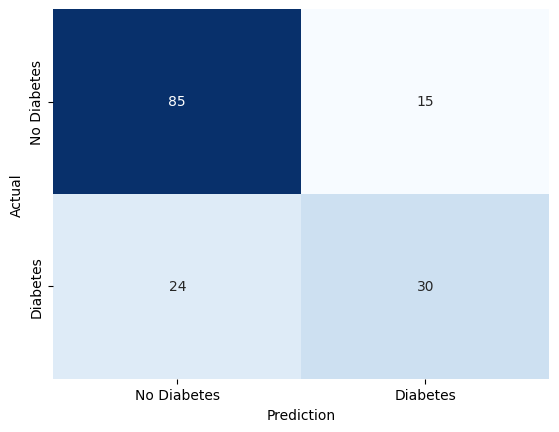

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Convert predicted probabilities to class labels (0 or 1)
y_test_pred = (model.predict(X_test) > 0.5).astype(int)

#The line above does the following:
#1. model.predict(X_test) gives the predicted probabilities
#2. > 0.5 converts probabilities to True/False based on threshold
#3. astype(int) converts True/False to 1/0

c_matrix = confusion_matrix(y_test, y_test_pred)
ax = sns.heatmap(c_matrix, annot=True,
                 xticklabels=['No Diabetes','Diabetes'],
                 yticklabels=['No Diabetes','Diabetes'],
                 cbar=False, cmap='Blues')
ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")

From the preceding confusion matrix, we can see that most predictions are true negatives
and true positives (as indicated by the 78.57% test accuracy in the previous section). The
remaining 24 predictions are false negatives and 15 other predictions are false positives,
which are undesirable.
For diabetes prediction, a false negative is perhaps more damaging than a false positive. A
false negative means telling the patient that they will not develop diabetes within the next
five years, when in fact they would. Therefore, when we evaluate the performance of
different models for predicting the onset of diabetes, a model with a lower false negative is
more desirable.

**ROC curve**
For classification tasks, we should also look at the ROC curve to evaluate our model. The
ROC curve is a plot with the True Positive Rate (TPR) on the y axis and the False Positive
Rate (FPR) on the x axis. TPR and FPR are defined as follows:

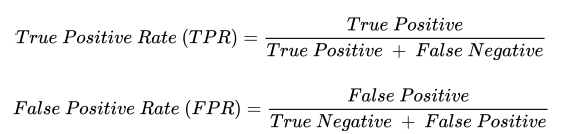

When we analyze the ROC curve, we look at the area under the curve (AUC) to evaluate
the performance of the model that produced the curve. A large AUC indicates that the
model is able to differentiate the respective classes with high accuracy, while a low AUC
indicates that the model makes poor, often wrong predictions. A ROC curve that lies on the
diagonal indicates that the model does no better than random.

Let's plot the ROC curve for our model and analyze its performance. As always, scikit-learn
provides a useful roc_curve class to help us do this. But first, let's get the predicted
probabilities of each class using the predict() function:

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
y_test_pred_probs = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


In [ ]:
#Then, run the roc_curve function in order to get the corresponding false positive rate and
#true positive rate for the ROC curve:
FPR, TPR, _ = roc_curve(y_test, y_test_pred_probs)
#Now plot the values on a plot using matplotlib:

Text(0, 0.5, 'True Positive Rate')

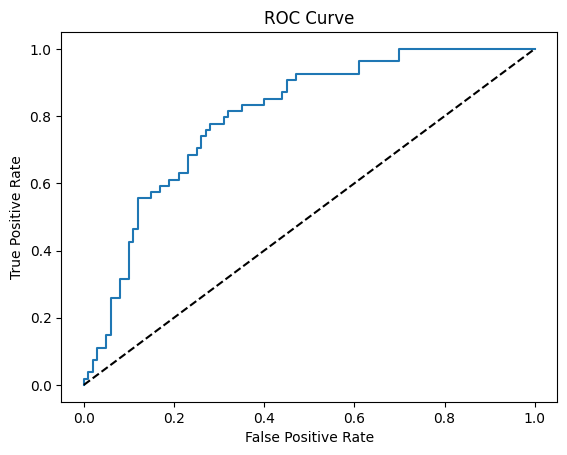

In [ ]:
plt.plot(FPR, TPR)
plt.plot([0,1],[0,1],'--', color='black') #diagonal line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')